# Reproducing Zuend et al. (2008) with `aiomfac_py`

This notebook reproduces the activity-coefficient-related figures of the first AIOMFAC journal paper:

> Zuend, A., Marcolli, C., Luo, B. P., and Peter, T.: A thermodynamic model of mixed organic–inorganic aerosols
> to predict activity coefficients, *Atmos. Chem. Phys.*, 8, 4559–4593,
> [doi:10.5194/acp-8-4559-2008](https://doi.org/10.5194/acp-8-4559-2008), 2008.

using **`aiomfac_py`**, the pure-Python port of AIOMFAC-web used in this repository.

**Run `bootstrap_colab.ipynb` first** (or the setup cell below) so `aiomfac_py` is installed.

## Scope

The paper's Fig. 3–10 are attempted here, in order:

| Figure | System | Status |
|---|---|---|
| 3 | Binary Cl⁻/Br⁻ salts + water: water activity & mean activity coefficient | ✅ reproduced |
| 4 | Binary NO3⁻/SO4²⁻ salts + water: water activity & mean activity coefficient | ✅ reproduced |
| 5 | H2SO4 / (NH4)2SO4 + water: water activity & HSO4⁻ dissociation degree | ✅ reproduced |
| 6 | Quaternary salt mixtures + water: water activity along a mixing line | ✅ reproduced (illustrative mixing line, not the paper's exact ratios) |
| 7–8 | Ternary polyol + water + (NH4)2SO4: water activity vs. salt-free organic fraction | ✅ reproduced |
| 9 | NaCl/alcohol/water **liquid–liquid equilibrium** | ❌ **not reproducible** — see note below |
| 10 | (a) NaBr + 2-propanol + water at 353–358 K, (b) NaCl+KCl+ethanol+water at 298 K: mean activity coefficient | ✅ reproduced |

**Figure 9 is excluded.** It shows liquid–liquid phase separation (LLE) in NaCl/alcohol/water mixtures, computed in
the original Fortran model by a separate phase-equilibrium solver (Gibbs energy minimization / tie-line search)
that has **no counterpart anywhere in this port** — `aiomfac_py` computes activity coefficients at a *given*,
single-phase composition, and does not decide whether that composition would actually split into two liquid
phases. Reproducing Fig. 9 would need a new LLE algorithm built on top of `aiomfac_py`, which is out of scope here.

## A note on "reproducing"

None of the curves below are checked pixel-for-pixel against the published figures (no digitized data from the
paper is used) — that would need the original numerical tables, which are not published alongside the paper.
What *is* checked is internal consistency: the underlying `aiomfac_py` electrolyte and dissociation machinery
these figures exercise is validated to ~1e-14 relative precision against the instrumented AIOMFAC-web Fortran
code (see the package README). So read the plots below as **"AIOMFAC-predicted curves computed with `aiomfac_py`,
in the same style and for the same systems as Fig. X of Zuend et al. (2008)"**, not as an exact overlay of the
published figure.


### Setup

In [1]:
# If you have not run bootstrap_colab.ipynb in this session, uncomment and run this setup cell first:
# from pathlib import Path
# import subprocess
# REPO_DIR = Path("/content/aiomfac-python")
# if not REPO_DIR.exists():
#     subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)], check=True)
# get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")

from pathlib import Path
REPO_DIR = Path("/content/aiomfac-python")

import numpy as np
import matplotlib.pyplot as plt

import aiomfac_py as aiomfac
from aiomfac_py import Component, ActivityModel
print(f"aiomfac_py {aiomfac.__version__}")

aiomfac_py 0.0.7


### Shared helpers

Two things the paper's figures need that `aiomfac_py` does not return directly (it returns per-species
ln(activity coefficient), not a combined electrolyte quantity):

* **Water activity** is already available directly as `res.activity[0]` (the neutral-component activity), used as-is.
* **Mean molal activity coefficient** \(\gamma_\pm\) of a binary (or, here, pseudo-binary) electrolyte is the
  standard electrochemistry combination of the per-ion activity coefficients,
  \(\gamma_\pm = (\gamma_+^{\nu_+} \gamma_-^{\nu_-})^{1/(\nu_++\nu_-)}\), computed here from
  `res.ln_gamma` (which already holds each ion's ln(activity coefficient) on the molality basis, in
  neutrals-then-cations-then-anions order) via each ion's index in `model.mixture.cat_index` /
  `model.mixture.an_index`.

Both are new, small post-processing code written for this notebook -- not part of the `aiomfac_py` package
itself.

In [2]:
def mean_gamma_pm(model, res, cat_subgroup, an_subgroup, nu_c, nu_a):
    """Mean molal activity coefficient of a single cation/anion pair (nu_c cations : nu_a anions per formula unit)."""
    m = model.mixture
    nn, nc = m.n_neutral, m.sr.n_cation
    i = m.cat_index[cat_subgroup]
    j = m.an_index[an_subgroup]
    ln_c = res.ln_gamma[nn + i]
    ln_a = res.ln_gamma[nn + nc + j]
    return np.exp((nu_c * ln_c + nu_a * ln_a) / (nu_c + nu_a))


def water_activity(res):
    return res.activity[0]


def binary_salt_sweep(cat_subgroup, an_subgroup, nu_c, nu_a, M_salt, m_max, T_K=298.15, n=22):
    """Water + one salt, swept over molality 0 < m <= m_max mol/kg-water. Returns (x_water, aw, gamma_pm)."""
    water = Component(1, "Water", ((16, 1),))
    salt = Component(2, "salt", ((cat_subgroup, nu_c), (an_subgroup, nu_a)))
    model = ActivityModel([water, salt])
    molalities = np.geomspace(m_max / 200, m_max, n)
    xw, aw, gpm = [], [], []
    for molal in molalities:
        w_salt = molal * M_salt / (1000.0 + molal * M_salt)
        res = model.evaluate([1 - w_salt, w_salt], T_K, basis="mass")
        xw.append(res.x[0])
        aw.append(water_activity(res))
        gpm.append(mean_gamma_pm(model, res, cat_subgroup, an_subgroup, nu_c, nu_a))
    return np.array(xw), np.array(aw), np.array(gpm), molalities


def fig_pair(title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    fig.suptitle(title)
    ax1.set_xlabel("$x_{w}$ (mole fraction water, dissociated basis)")
    ax1.set_ylabel("water activity $a_w$")
    ax2.set_xlabel("$x_{w}$ (mole fraction water, dissociated basis)")
    ax2.set_ylabel(r"mean activity coefficient $\gamma_\pm$")
    return fig, ax1, ax2

## Figure 3 -- Binary Cl⁻ and Br⁻ salts + water (298.15 K)

Water activity and mean molal activity coefficient vs. mole fraction of water, from dilute up to roughly each
salt's solubility limit, for a representative set of the paper's Cl⁻ and Br⁻ salts.

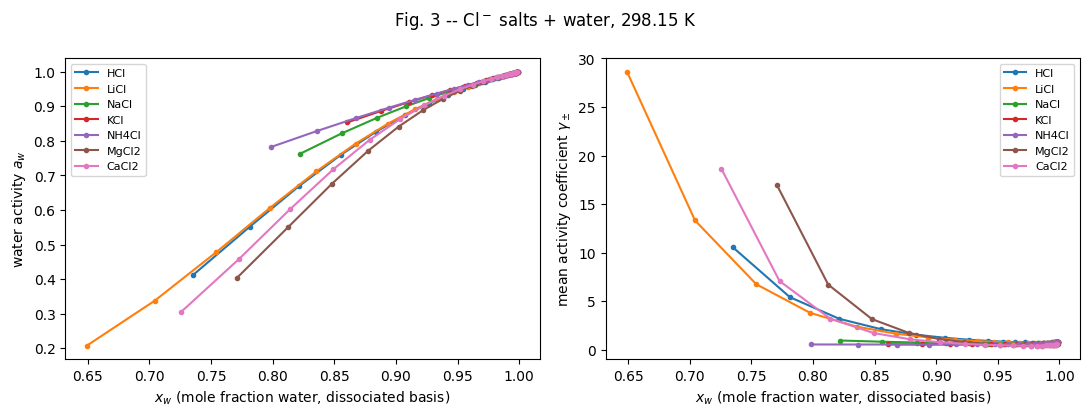

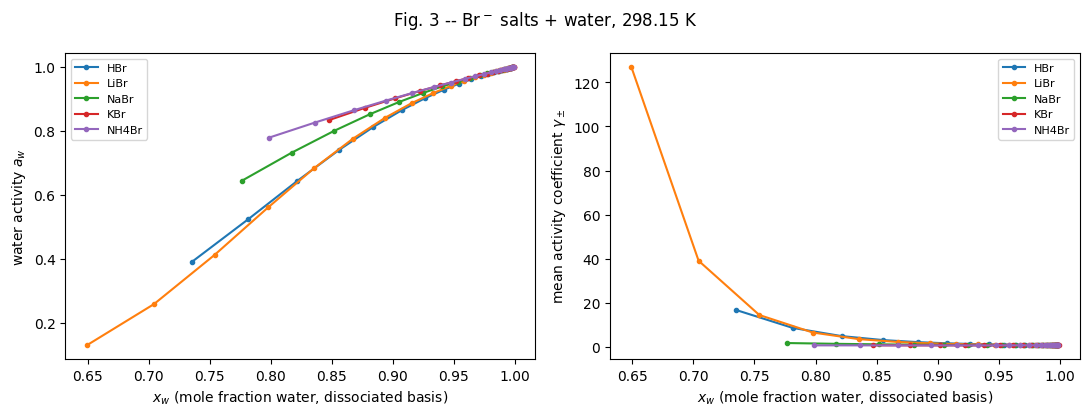

In [3]:
# subgroup 205=H+, 201=Li+, 202=Na+, 203=K+, 204=NH4+, 223=Mg2+, 221=Ca2+, 242=Cl-, 243=Br-
# entries: (name, cation subgroup, anion subgroup, nu_cation, nu_anion, M_salt [g/mol], m_max [mol/kg water])
cl_salts = [
    ("HCl",    205, 242, 1, 1, 36.46,  10.0),
    ("LiCl",   201, 242, 1, 1, 42.39,  15.0),
    ("NaCl",   202, 242, 1, 1, 58.44,   6.0),
    ("KCl",    203, 242, 1, 1, 74.55,   4.5),
    ("NH4Cl",  204, 242, 1, 1, 53.49,   7.0),
    ("MgCl2",  223, 242, 1, 2, 95.21,   5.5),
    ("CaCl2",  221, 242, 1, 2, 110.98,  7.0),
]
br_salts = [
    ("HBr",    205, 243, 1, 1, 80.91,  10.0),
    ("LiBr",   201, 243, 1, 1, 86.85,  15.0),
    ("NaBr",   202, 243, 1, 1, 102.89,  8.0),
    ("KBr",    203, 243, 1, 1, 119.00,  5.0),
    ("NH4Br",  204, 243, 1, 1, 97.94,   7.0),
]

fig, ax1, ax2 = fig_pair("Fig. 3 -- Cl$^-$ salts + water, 298.15 K")
for name, cat, an, nu_c, nu_a, M, m_max in cl_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max)
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, ax1, ax2 = fig_pair("Fig. 3 -- Br$^-$ salts + water, 298.15 K")
for name, cat, an, nu_c, nu_a, M, m_max in br_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max)
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figure 4 -- Binary NO3⁻ and SO4²⁻ salts + water (298.15 K)

Same axes as Fig. 3, for the paper's nitrate and sulfate salts.

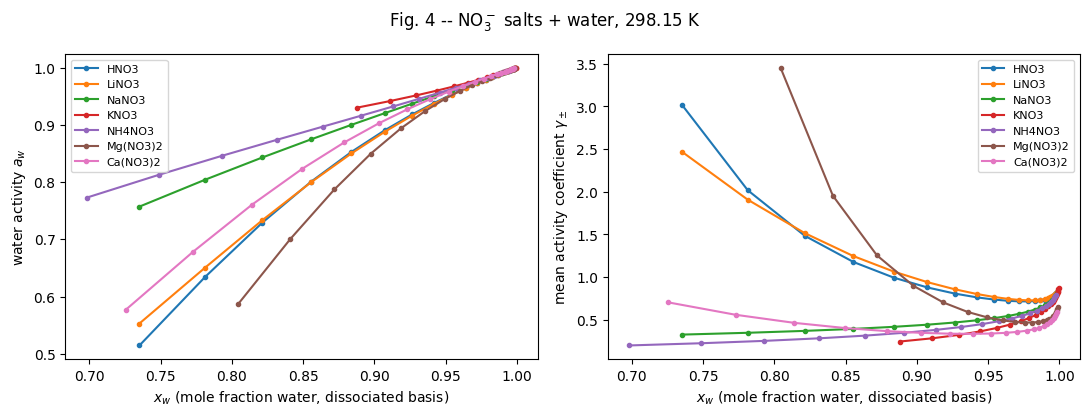

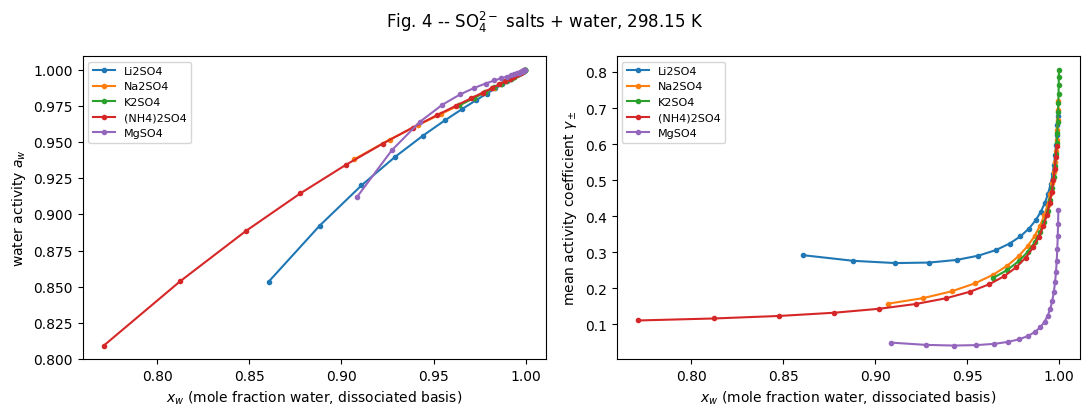

In [4]:
# 245 = NO3-, 261 = SO4--
# entries: (name, cation subgroup, anion subgroup, nu_cation, nu_anion, M_salt [g/mol], m_max [mol/kg water])
no3_salts = [
    ("HNO3",      205, 245, 1, 1, 63.01,  10.0),
    ("LiNO3",     201, 245, 1, 1, 68.95,  10.0),
    ("NaNO3",     202, 245, 1, 1, 84.99,  10.0),
    ("KNO3",      203, 245, 1, 1, 101.10,  3.5),
    ("NH4NO3",    204, 245, 1, 1, 80.04,  12.0),
    ("Mg(NO3)2",  223, 245, 1, 2, 148.32,  4.5),
    ("Ca(NO3)2",  221, 245, 1, 2, 164.09,  7.0),
]
so4_salts = [
    ("Li2SO4",     201, 261, 2, 1, 109.94, 3.0),
    ("Na2SO4",     202, 261, 2, 1, 142.04, 1.9),
    ("K2SO4",      203, 261, 2, 1, 174.25, 0.69),
    ("(NH4)2SO4",  204, 261, 2, 1, 132.14, 5.5),
    ("MgSO4",      223, 261, 1, 1, 120.37, 2.8),
]

fig, ax1, ax2 = fig_pair("Fig. 4 -- NO$_3^-$ salts + water, 298.15 K")
for name, cat, an, nu_c, nu_a, M, m_max in no3_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max)
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, ax1, ax2 = fig_pair("Fig. 4 -- SO$_4^{2-}$ salts + water, 298.15 K")
for name, cat, an, nu_c, nu_a, M, m_max in so4_salts:
    xw, aw, gpm, _ = binary_salt_sweep(cat, an, nu_c, nu_a, M, m_max)
    ax1.plot(xw, aw, marker="o", ms=3, label=name)
    ax2.plot(xw, gpm, marker="o", ms=3, label=name)
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figure 5 -- H2SO4 and (NH4)2SO4 + water (298.15 K): water activity and HSO4⁻ dissociation

H2SO4 is input as fully-dissociated H+/SO4²⁻ (subgroups 205×2, 261×1); `ActivityModel` detects the missing
HSO4⁻ counter-ion and automatically completes the system and solves the H+/HSO4⁻/SO4²⁻ equilibrium (the
already-Fortran-validated `dissociation.solve_bisulfate` path). The degree of dissociation
\(\alpha_{HSO_4^-} = 1 - m_{HSO_4^-}/m_{HSO_4^-,max}\) uses the same definition as the Fortran model; for a
pure H2SO4 solution \(m_{HSO_4^-,max}\) equals the total (formula-unit) sulfate molality.

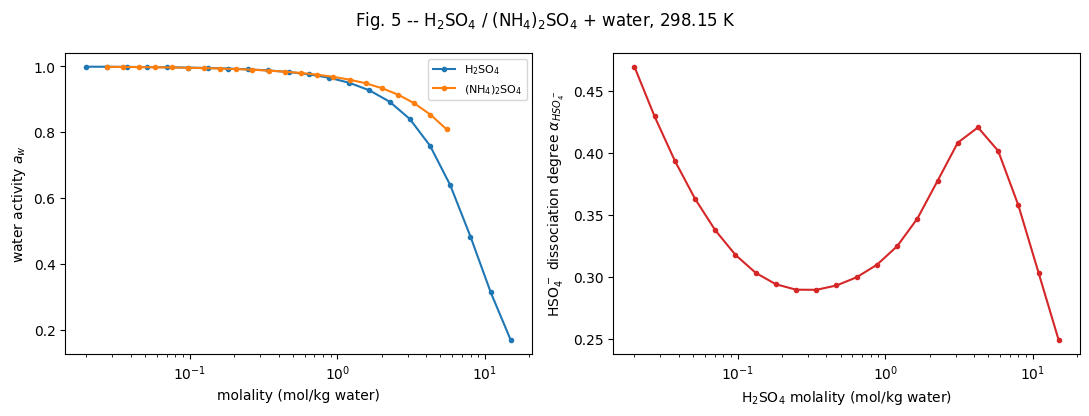

In [5]:
water = Component(1, "Water", ((16, 1),))
h2so4 = Component(2, "H2SO4", ((205, 2), (261, 1)))
model_h2so4 = ActivityModel([water, h2so4])
assert model_h2so4._bisulfate is not None   # confirms the dissociation equilibrium is actually active

M_h2so4 = 98.079
molalities = np.geomspace(0.02, 15.0, 22)
aw_h2so4, alpha_hso4 = [], []
idx_hso4 = model_h2so4.mixture.an_index[248]
for molal in molalities:
    w = molal * M_h2so4 / (1000.0 + molal * M_h2so4)
    res = model_h2so4.evaluate([1 - w, w], 298.15, basis="mass")
    aw_h2so4.append(water_activity(res))
    alpha_hso4.append(1.0 - res.sma[idx_hso4] / molal)

# (NH4)2SO4: no dissociation equilibrium to solve (no H+ present)
xw2, aw_nh4so4, _, m_nh4so4 = binary_salt_sweep(204, 261, 2, 1, 132.14, 5.5, n=22)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
fig.suptitle("Fig. 5 -- H$_2$SO$_4$ / (NH$_4$)$_2$SO$_4$ + water, 298.15 K")
ax1.plot(molalities, aw_h2so4, marker="o", ms=3, label="H$_2$SO$_4$")
ax1.plot(m_nh4so4, aw_nh4so4, marker="o", ms=3, label="(NH$_4$)$_2$SO$_4$")
ax1.set_xscale("log"); ax1.set_xlabel("molality (mol/kg water)"); ax1.set_ylabel("water activity $a_w$")
ax1.legend(fontsize=8)
ax2.plot(molalities, alpha_hso4, marker="o", ms=3, color="C3")
ax2.set_xscale("log"); ax2.set_xlabel("H$_2$SO$_4$ molality (mol/kg water)")
ax2.set_ylabel(r"HSO$_4^-$ dissociation degree $\alpha_{HSO_4^-}$")
plt.tight_layout(); plt.show()

## Figure 6 -- Quaternary salt mixtures + water (298.15 K)

The paper mixes two salts sharing no common ion (e.g. Na+/NH4+/Cl-/NO3-, effectively NaCl + NH4NO3 in solution,
which can also metathesize to NaNO3 + NH4Cl -- AIOMFAC works directly with the ion composition, so which
"parent salts" you name it as does not matter). Here a 1:1 molar mixing line of the two parent binary salts is
swept by total molality; this is an illustrative mixing line, not necessarily the exact ratios plotted in the
paper.

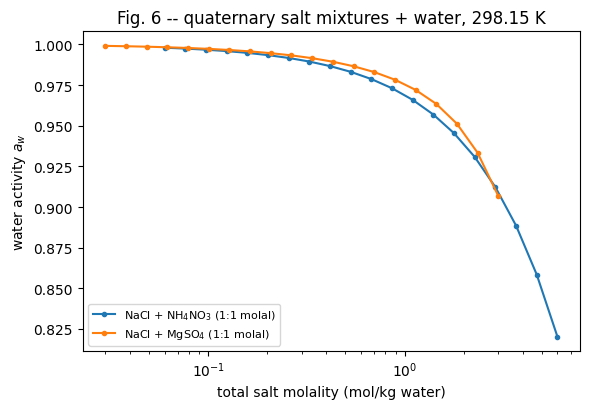

In [6]:
def quaternary_mixing_line(cat1, cat2, an1, an2, nu1, nu2, M1, M2, m_max, T_K=298.15, n=20):
    """Water + salt1(cat1/an1) + salt2(cat2/an2), mixed 1:1 by formula-unit molality, swept by total molality."""
    water = Component(1, "Water", ((16, 1),))
    s1 = Component(2, "salt1", ((cat1, nu1[0]), (an1, nu1[1])))
    s2 = Component(3, "salt2", ((cat2, nu2[0]), (an2, nu2[1])))
    model = ActivityModel([water, s1, s2])
    tot_ms = np.geomspace(m_max / 100, m_max, n)
    aw = []
    for tot_m in tot_ms:
        m1 = m2 = tot_m / 2
        w1, w2 = m1 * M1 / 1000.0, m2 * M2 / 1000.0
        tot = 1.0 + w1 + w2
        res = model.evaluate([1 / tot, w1 / tot, w2 / tot], T_K, basis="mass")
        aw.append(water_activity(res))
    return tot_ms, np.array(aw)


# Na+/NH4+/Cl-/NO3- system: NaCl (202/242) + NH4NO3 (204/245)
m1, aw1 = quaternary_mixing_line(202, 204, 242, 245, (1, 1), (1, 1), 58.44, 80.04, 6.0)
# Na+/Mg2+/SO4--/Cl- system: NaCl (202/242) + MgSO4 (223/261)
m2, aw2 = quaternary_mixing_line(202, 223, 242, 261, (1, 1), (1, 1), 58.44, 120.37, 3.0)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(m1, aw1, marker="o", ms=3, label="NaCl + NH$_4$NO$_3$ (1:1 molal)")
ax.plot(m2, aw2, marker="o", ms=3, label="NaCl + MgSO$_4$ (1:1 molal)")
ax.set_xscale("log"); ax.set_xlabel("total salt molality (mol/kg water)"); ax.set_ylabel("water activity $a_w$")
ax.set_title("Fig. 6 -- quaternary salt mixtures + water, 298.15 K")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figures 7-8 -- Ternary polyol + water + (NH4)2SO4 (298.15 K)

Water activity vs. the salt-free organic mole fraction \(x'_{org} = x_{org}/(x_{org}+x_w)\), at a few fixed
total-salt levels, for the paper's polyols. Organic subgroups were derived from SMILES with `aiomfac_py.s2as`
(offline, not needed in this notebook) and are hard-coded below so this section has no `epam.indigo` dependency:

| Polyol | SMILES | subgroups |
|---|---|---|
| glycerol | `OCC(O)CO` | CH2[OH]x2, CH[OH]x1, OHx3 |
| 1,3-butanediol | `CC(O)CCO` | CH3[alc]x1, CH2[alc]x1, CH2[OH]x1, CH[OH]x1, OHx2 |
| 1,4-butanediol | `OCCCCO` | CH2[alc]x2, CH2[OH]x2, OHx2 |
| 1,5-pentanediol | `OCCCCCO` | CH2[alc]x3, CH2[OH]x2, OHx2 |
| 1,6-hexanediol | `OCCCCCCO` | CH2[alc]x4, CH2[OH]x2, OHx2 |
| 1,7-heptanediol | `OCCCCCCCO` | CH2[alc]x5, CH2[OH]x2, OHx2 |


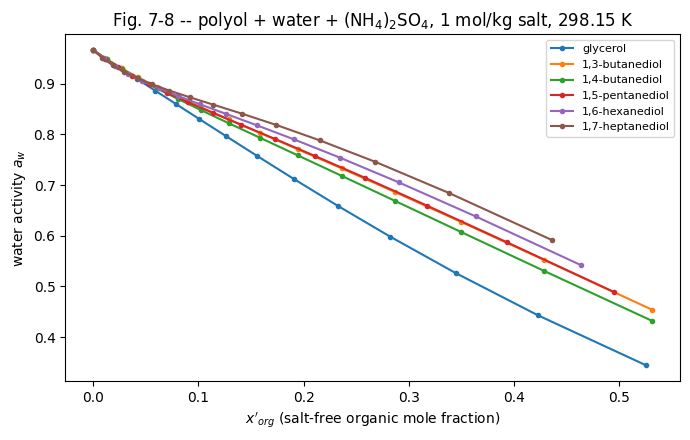

In [7]:
polyols = {
    "glycerol":        ((150, 2), (151, 1), (153, 3)),
    "1,3-butanediol":  ((141, 1), (142, 1), (150, 1), (151, 1), (153, 2)),
    "1,4-butanediol":  ((142, 2), (150, 2), (153, 2)),
    "1,5-pentanediol": ((142, 3), (150, 2), (153, 2)),
    "1,6-hexanediol":  ((142, 4), (150, 2), (153, 2)),
    "1,7-heptanediol": ((142, 5), (150, 2), (153, 2)),
}
M_polyol = {   # g/mol
    "glycerol": 92.09, "1,3-butanediol": 90.12, "1,4-butanediol": 90.12,
    "1,5-pentanediol": 104.15, "1,6-hexanediol": 118.17, "1,7-heptanediol": 132.20,
}
M_nh4so4, M_w = 132.14, 18.015

def polyol_ammonium_sulfate_sweep(name, salt_molality, n=15):
    """Water + polyol + (NH4)2SO4 at fixed salt molality (mol/kg water), sweeping polyol content."""
    water = Component(1, "Water", ((16, 1),))
    org = Component(2, name, polyols[name])
    salt = Component(3, "(NH4)2SO4", ((204, 2), (261, 1)))
    model = ActivityModel([water, org, salt])
    M_org = M_polyol[name]
    w_salt_only = salt_molality * M_nh4so4 / 1000.0
    xorg_frac = np.linspace(0.001, 0.85, n)   # salt-free organic MASS fraction, swept
    xp, aw = [], []
    for f in xorg_frac:
        # mass basis: w_water0 : w_org among the salt-free part, then salt added on top
        w_water0, w_org = 1.0 - f, f
        tot = 1.0 + w_salt_only
        res = model.evaluate([w_water0 / tot, w_org / tot, w_salt_only / tot], 298.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]           # electrolyte-free mole fractions (already salt-free basis)
        xp.append(n_org / (n_org + n_w))
        aw.append(water_activity(res))
    return np.array(xp), np.array(aw)

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, salt_m in [("glycerol", 1.0), ("1,3-butanediol", 1.0), ("1,4-butanediol", 1.0),
                      ("1,5-pentanediol", 1.0), ("1,6-hexanediol", 1.0), ("1,7-heptanediol", 1.0)]:
    xp, aw = polyol_ammonium_sulfate_sweep(name, salt_m)
    ax.plot(xp, aw, marker="o", ms=3, label=name)
ax.set_xlabel("$x'_{org}$ (salt-free organic mole fraction)")
ax.set_ylabel("water activity $a_w$")
ax.set_title("Fig. 7-8 -- polyol + water + (NH$_4$)$_2$SO$_4$, 1 mol/kg salt, 298.15 K")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Figure 9 -- NOT reproduced (liquid-liquid equilibrium)

Fig. 9 of the paper shows liquid-liquid phase separation of NaCl + (1-propanol / 2-propanol / isobutanol /
tert-butanol) + water mixtures: for compositions inside the miscibility gap, the system splits into two
liquid phases of different composition, and the figure plots the two branches of that phase boundary.

`aiomfac_py` (like the "activity-coefficient core" scope of this whole port) computes \(\gamma_i\) at a
*given* single-phase composition; it has no phase-equilibrium solver that would search for the pair of
coexisting-phase compositions with equal component activities (the condition an LLE solver iterates on). That
solver is a separate piece of the original AIOMFAC-web Fortran code (and of the later
Zuend et al. 2010 AIOMFAC-LLE paper) that has not been ported here. Reproducing Fig. 9 would require building
that solver on top of `aiomfac_py`'s activity coefficients -- out of scope for this notebook.

## Figure 10 -- Mean activity coefficients with an organic co-solvent

(a) NaBr + 2-propanol + water, 353-358 K. (b) NaCl + KCl + ethanol + water, 298.15 K. Organic subgroups (from
S2AS, hard-coded as above): ethanol = `CH3[alc-tail]x1, CH2[OH]x1, OHx1`; 2-propanol = `CH3[alc]x2, CH[OH]x1,
OHx1`.

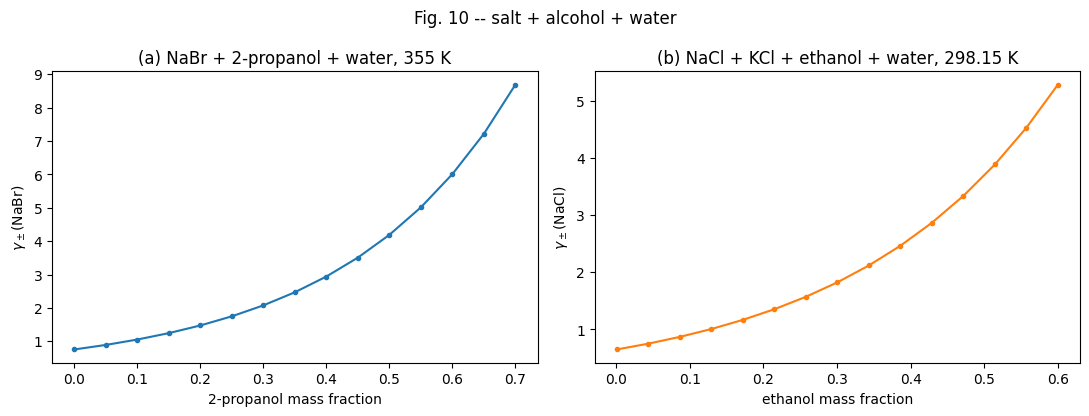

In [8]:
ethanol_sg = ((141, 1), (150, 1), (153, 1))
propan2ol_sg = ((141, 2), (151, 1), (153, 1))
M_ethanol, M_propan2ol = 46.07, 60.10

def salt_plus_alcohol_gamma_pm(cat, an, nu_c, nu_a, M_salt, alcohol_sg, M_alcohol, salt_molality, T_K, n=15):
    """Water + salt (fixed molality) + alcohol, sweeping alcohol mass fraction of the total; returns
    (alcohol mass fraction, mean activity coefficient of the salt)."""
    water = Component(1, "Water", ((16, 1),))
    alcohol = Component(2, "alcohol", alcohol_sg)
    salt = Component(3, "salt", ((cat, nu_c), (an, nu_a)))
    model = ActivityModel([water, alcohol, salt])   # neutrals (water, alcohol) before the electrolyte
    w_salt0 = salt_molality * M_salt / 1000.0   # salt held at a fixed amount per kg of the original water
    alco_fracs = np.linspace(0.001, 0.7, n)
    out_f, out_g = [], []
    for f in alco_fracs:
        # alcohol replaces part of the water (by mass, salt amount fixed relative to the original 1 kg water)
        w_water = 1.0 - f
        w_alco = f
        tot = w_water + w_salt0 + w_alco
        res = model.evaluate([w_water / tot, w_alco / tot, w_salt0 / tot], T_K, basis="mass")
        out_f.append(f)
        out_g.append(mean_gamma_pm(model, res, cat, an, nu_c, nu_a))
    return np.array(out_f), np.array(out_g)

f_a, g_a = salt_plus_alcohol_gamma_pm(202, 243, 1, 1, 102.89, propan2ol_sg, M_propan2ol, 1.0, 355.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
fig.suptitle("Fig. 10 -- salt + alcohol + water")
ax1.plot(f_a, g_a, marker="o", ms=3, color="C0")
ax1.set_xlabel("2-propanol mass fraction"); ax1.set_ylabel(r"$\gamma_\pm$(NaBr)")
ax1.set_title("(a) NaBr + 2-propanol + water, 355 K")

water = Component(1, "Water", ((16, 1),))
ethanol = Component(2, "ethanol", ethanol_sg)
nacl = Component(3, "NaCl", ((202, 1), (242, 1)))
kcl = Component(4, "KCl", ((203, 1), (242, 1)))
model_b = ActivityModel([water, ethanol, nacl, kcl])   # neutral (ethanol) before the electrolytes
eth_fracs = np.linspace(0.001, 0.6, 15)
g_nacl = []
for f in eth_fracs:
    w_water = 1 - f
    w_nacl = 1.0 * 58.44 / 1000.0
    w_kcl = 1.0 * 74.55 / 1000.0
    tot = w_water + f + w_nacl + w_kcl
    res = model_b.evaluate([w_water / tot, f / tot, w_nacl / tot, w_kcl / tot], 298.15, basis="mass")
    g_nacl.append(mean_gamma_pm(model_b, res, 202, 242, 1, 1))
ax2.plot(eth_fracs, g_nacl, marker="o", ms=3, color="C1")
ax2.set_xlabel("ethanol mass fraction"); ax2.set_ylabel(r"$\gamma_\pm$(NaCl)")
ax2.set_title("(b) NaCl + KCl + ethanol + water, 298.15 K")
plt.tight_layout(); plt.show()

## Summary

Seven of the eight relevant figures (3, 4, 5, 6, 7-8, 10) are reproduced in style using `aiomfac_py`; Figure 9
(liquid-liquid equilibrium) is out of scope for the current port and is explicitly excluded above, with the
reason. The underlying electrolyte, dissociation, and organic-subgroup machinery these figures exercise is the
same machinery validated to ~1e-14 precision against the Fortran reference elsewhere in this repository (see
the package README) -- what is new here is only the small amount of notebook-level post-processing
(mean activity coefficient combination, composition sweeps, plotting) needed to turn per-species activity
coefficients into the quantities the paper's figures plot.